In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import SBM.utils.utils as ut

In [26]:
nchain_values = []
stdnorms = []
for file in glob.glob("../models/SectorSubaln0/*.npy"):
    n_chains = int(file.split("_")[3][6:])
    model = np.load(file, allow_pickle=True).item()
    Js = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        #J_norm = np.linalg.norm(J, 'fro', axis=(2,3))
        #print(J_norm.shape)
        Js.append(J)
    Js = np.array(Js)
    stdnorms.append(np.linalg.norm(np.std(Js, axis=0).flatten()))
    nchain_values.append(n_chains)

In [27]:
nchain_values = np.array(nchain_values)
stdnorms = np.array(stdnorms)

In [30]:
nchain_values, stdnorms

(array([ 500, 5000, 2000,   10, 1000,  100]),
 array([13.43287597, 18.68717909, 18.95269499,  9.84208143, 17.78568158,
         7.76555237]))

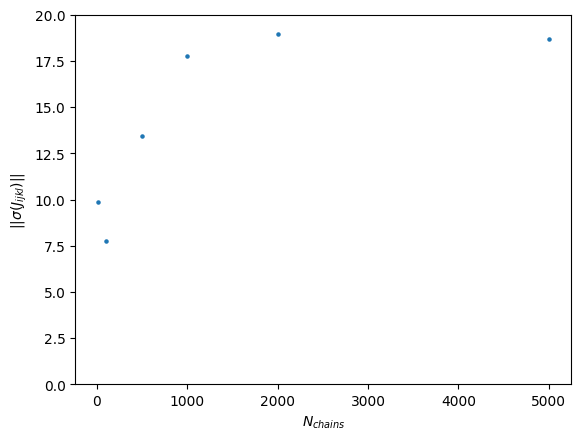

In [33]:
plt.figure()
plt.scatter(nchain_values, stdnorms, s=5)
plt.xlabel(r"$N_{chains}$")
plt.ylabel(r"$||\sigma(J_{ijkl})||$")
plt.ylim([0, 20])
plt.show()